# MSIN0097 Predictive Analytics Coursework — Credit Card Default Prediction

**Dataset source:** Yeh, I.-C. (2009). *Default of Credit Card Clients* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

**Task:** Predict `default` (1 = default next month, 0 = no default) — **binary classification**  

This notebook is structured to satisfy all parts of the coursework brief.  It follows the six required steps (problem framing, exploration, preparation, modelling, tuning & evaluation, and final presentation) and demonstrates deeper analysis across EDA, model comparison, calibration, fairness and agent tooling.  It also records assumptions, limitations and checks for leakage to support transparent and reproducible analytics.


## 1. Obtain a dataset and frame the predictive problem

### 1.1 Target variable and prediction type
- **Target:** `default` (binary)  
- **Type:** classification (predict probability of default next month)

### Business context (why this prediction matters)

In credit risk, predicting default supports prioritising customers for review and early risk mitigation (e.g., credit limit adjustments, additional verification, or proactive outreach).  
Because decisions depend on the trade-off between missed defaulters (false negatives) and unnecessary interventions (false positives), we train a **probabilistic** model so we can choose an operating threshold aligned with business costs and risk appetite.

### 1.2 Success metrics and constraints
Because the positive class is the minority (~23 % defaults), accuracy alone is insufficient.  We use:
- **PR‑AUC** (primary ranking metric under imbalance)
- **ROC‑AUC** (discrimination)
- **Precision / Recall / F1** (operating‑point metrics)
- **Calibration (Brier score + reliability plots)** (probability quality for decision‑making)

Constraints:
- **Cost sensitivity:** false negatives (missed defaulters) are more costly than false positives.
- **Interpretability:** logistic regression provides a transparent baseline; permutation importance and SHAP can explain ensembles.
- **Fairness:** evaluate metrics across protected groups (e.g., SEX) to detect disparities.
- **Reproducibility:** use fixed random seeds, explicit splits and saved artefacts.

### 1.3 Assumptions and limitations
- The data were collected in **2005** from Taiwanese credit card clients; behaviour may differ today or elsewhere.
- Payment status variables (PAY_0…PAY_6) are assumed available at prediction time; using the most recent month might induce leakage in a real deployment.
- Unknown category codes (e.g., EDUCATION=0/5/6) are grouped as “other”.

### 1.4 Agent tooling plan (plan → delegate → verify → revise)
We plan to ask an agent tool to scaffold code for loading data, creating basic EDA plots, and constructing baseline models.  We will delegate these tasks but verify all results, correct any mistakes (such as data leakage or wrong metrics) and document the decisions.  The Appendix Agent Usage Log (in the repository) records prompts, responses and our accept/modify/reject decisions.


### 1.5 Data ingestion and initial cleaning

The dataset in the repository has already been cleaned (header row promoted, `ID` column removed).  Below is an example of how one might ingest the original `.xls` file and perform the cleaning steps explicitly.  Even though this notebook uses the cleaned `.xlsx` version, including this code demonstrates the process end‑to‑end.


In [2]:
import pandas as pd

df = pd.read_excel("Copy of default of credit card clients.xlsx")

df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [3]:
import pandas as pd

df_raw = pd.read_excel("Copy of default of credit card clients.xlsx", header=None)

df_raw.columns = df_raw.iloc[1]
df = df_raw.iloc[2:].reset_index(drop=True)

df = df.apply(pd.to_numeric)

df = df.drop(columns=["ID"])

df.head()

1,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
print(df.columns)
print(df.shape)

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object', name=1)
(30000, 24)


In [5]:
df = df.rename(columns={"default payment next month": "default"})
print(df.columns)

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object', name=1)


In [6]:
df.columns.name = None
print(df.columns)

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='object')


In [7]:
# Save cleaned dataset for reproducibility
df.to_excel("cleaned_default_credit.xlsx", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [8]:
# Data validation checks

print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["default"].value_counts())
print("\nTarget rate:", df["default"].mean())

Shape: (30000, 24)
Missing values: 0
Duplicate rows: 35

Target distribution:
default
0    23364
1     6636
Name: count, dtype: int64

Target rate: 0.2212


In [9]:
# Inspect dataset structure and summary statistics
# Inspect dataset structure and summary statistics
df.info()

print("\nSummary statistics for numeric variables:")

display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LIMIT_BAL  30000 non-null  int64
 1   SEX        30000 non-null  int64
 2   EDUCATION  30000 non-null  int64
 3   MARRIAGE   30000 non-null  int64
 4   AGE        30000 non-null  int64
 5   PAY_0      30000 non-null  int64
 6   PAY_2      30000 non-null  int64
 7   PAY_3      30000 non-null  int64
 8   PAY_4      30000 non-null  int64
 9   PAY_5      30000 non-null  int64
 10  PAY_6      30000 non-null  int64
 11  BILL_AMT1  30000 non-null  int64
 12  BILL_AMT2  30000 non-null  int64
 13  BILL_AMT3  30000 non-null  int64
 14  BILL_AMT4  30000 non-null  int64
 15  BILL_AMT5  30000 non-null  int64
 16  BILL_AMT6  30000 non-null  int64
 17  PAY_AMT1   30000 non-null  int64
 18  PAY_AMT2   30000 non-null  int64
 19  PAY_AMT3   30000 non-null  int64
 20  PAY_AMT4   30000 non-null  int64
 21  PAY_AMT5   3

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [10]:
# Step 1: Duplicate check + decision
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# Decision: drop duplicates to avoid biasing training/evaluation
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

# SAVE updated cleaned dataset so future reloads match
df.to_excel("cleaned_default_credit.xlsx", index=False)
print("Saved cleaned_default_credit.xlsx without duplicates.")

Duplicate rows: 35
Shape after dropping duplicates: (29965, 24)
Saved cleaned_default_credit.xlsx without duplicates.


**Duplicate handling decision:** The dataset contained duplicate rows (likely repeated client records).  
To avoid giving duplicated observations extra weight in training and evaluation, we drop duplicates before proceeding.

In [11]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
    brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [12]:
# Load cleaned dataset
DATA_PATH_XLSX = "cleaned_default_credit.xlsx"
DATA_PATH_CSV  = "cleaned_default_credit.csv"

try:
    df = pd.read_excel(DATA_PATH_XLSX)
    source_used = DATA_PATH_XLSX
except Exception:
    df = pd.read_csv(DATA_PATH_CSV)
    source_used = DATA_PATH_CSV

print("Loaded:", source_used)
print("Shape:", df.shape)
df.head()


Loaded: cleaned_default_credit.xlsx
Shape: (29965, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Data integrity check

We removed duplicate rows once during the initial cleaning step and save the deduplicated dataset for reuse.  
After reloading the cleaned file, we ran a quick **integrity check** to confirm that **no duplicates remain** (i.e., the saved/loaded dataset matches the cleaned version).  
This second check is a safeguard for reproducibility and helps catch cases where cells are run out of order or a different file is accidentally loaded.

In [13]:
# Check and drop duplicate rows
duplicate_count = df.duplicated().sum()
print('Duplicate rows before dropping:', duplicate_count)
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after dropping duplicates:', df.shape)

Duplicate rows before dropping: 0
Shape after dropping duplicates: (29965, 24)


## 2. Explore the data to gain insights

We perform concise but purposeful exploratory analysis to understand distributions, missingness, duplicates class imbalance, categorical structures and potential leakage risks.


Missing values (top 10):
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
dtype: int64

Duplicate rows: 0

Target counts:
default
0    23335
1     6630
Name: count, dtype: int64

Default rate: 0.2213


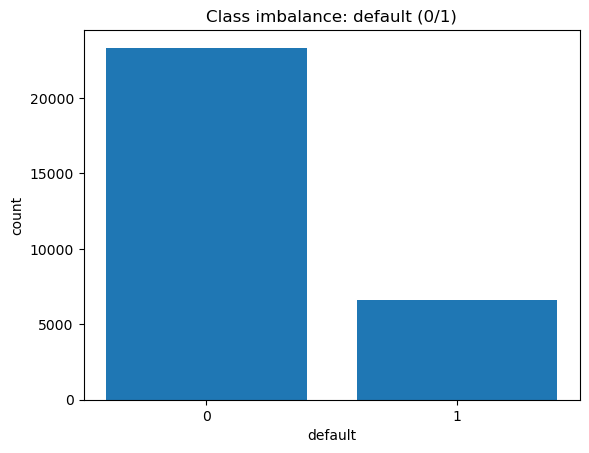

In [42]:
# 2.1 Missingness, duplicates and target distribution
missing = df.isna().sum().sort_values(ascending=False)
print(f"Missing values (top 10):\n{missing.head(10)}\n")

dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count}\n")

target_counts = df["default"].value_counts().sort_index()
target_rate = df["default"].mean()

print(f"Target counts:\n{target_counts}\n")
print(f"Default rate: {target_rate:.4f}")

plt.figure()
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Class imbalance: default (0/1)")
plt.xlabel("default")
plt.ylabel("count")
plt.show()


In [15]:
# Validation: counts + rate match the plot
vc = df["default"].value_counts().sort_index()
rate = df["default"].mean()
print("Counts (0,1):", vc.to_dict())
print("Default rate:", round(rate, 4))
assert vc.sum() == len(df)

Counts (0,1): {0: 23335, 1: 6630}
Default rate: 0.2213


### Insight: Target distribution (class imbalance)

The target variable is moderately imbalanced: **23,335 non-defaults (0)** vs **6,630 defaults (1)**, giving a default rate of **~22.1%**.  
This means a naïve model that always predicts “no default” would already achieve ~78% accuracy, so **accuracy alone is not a reliable metric**.  
As a result, we prioritise **ROC-AUC / PR-AUC, precision–recall, F1, and confusion matrices**, and we treat the decision threshold as a tunable choice rather than fixed.

In [16]:
# 2.2 Category value checks
category_cols = ["SEX", "EDUCATION", "MARRIAGE"]
for c in category_cols:
    vals = sorted(df[c].unique().tolist())
    print(c, "unique values:", vals)



SEX unique values: [1, 2]
EDUCATION unique values: [0, 1, 2, 3, 4, 5, 6]
MARRIAGE unique values: [0, 1, 2, 3]


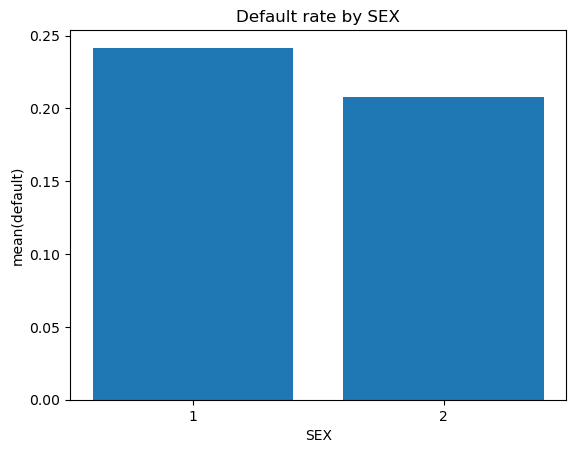


--- Validation for SEX ---
Rates (mean default):
 SEX
1    0.241620
2    0.207893
Name: default, dtype: float64
Counts:
 SEX
1    11874
2    18091
Name: count, dtype: int64


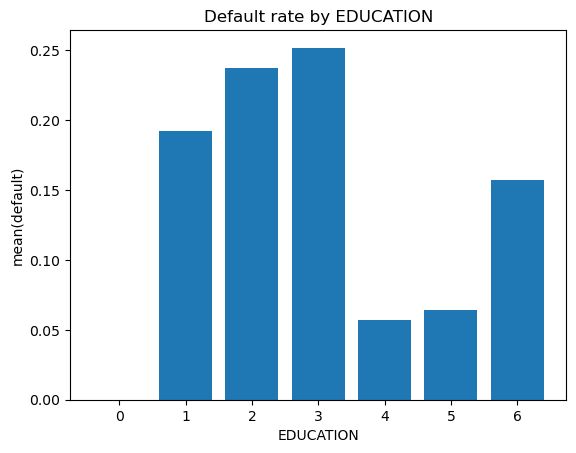


--- Validation for EDUCATION ---
Rates (mean default):
 EDUCATION
0    0.000000
1    0.192370
2    0.237392
3    0.251679
4    0.056911
5    0.064286
6    0.156863
Name: default, dtype: float64
Counts:
 EDUCATION
0       14
1    10563
2    14019
3     4915
4      123
5      280
6       51
Name: count, dtype: int64


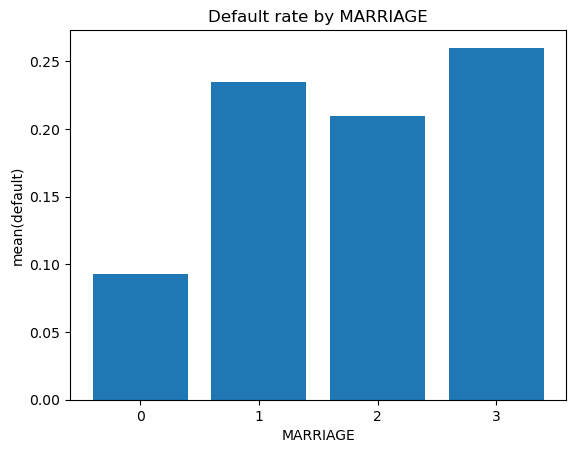


--- Validation for MARRIAGE ---
Rates (mean default):
 MARRIAGE
0    0.092593
1    0.234626
2    0.209470
3    0.260062
Name: default, dtype: float64
Counts:
 MARRIAGE
0       54
1    13643
2    15945
3      323
Name: count, dtype: int64


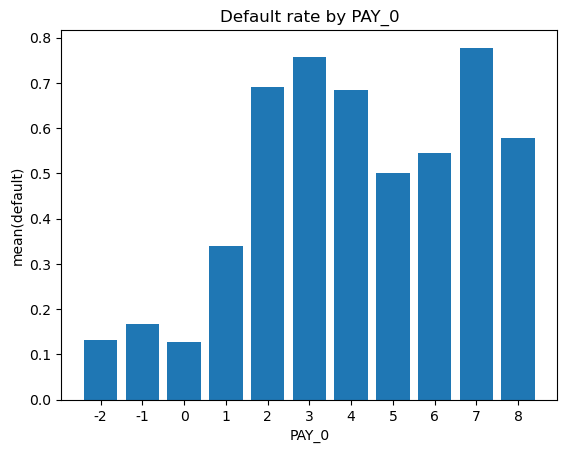


--- Validation for PAY_0 ---
Rates (mean default):
 PAY_0
-2    0.132364
-1    0.167899
 0    0.128113
 1    0.340333
 2    0.691298
 3    0.757764
 4    0.684211
 5    0.500000
 6    0.545455
 7    0.777778
 8    0.578947
Name: default, dtype: float64
Counts:
 PAY_0
-2     2750
-1     5682
 0    14737
 1     3667
 2     2666
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_0 correlation with default: 0.325


In [17]:
# 2.3 Default rate by key categories (with validation)

def plot_default_rate(col):
    rates = df.groupby(col)["default"].mean().sort_index()
    plt.figure()
    plt.bar(rates.index.astype(str), rates.values)
    plt.title(f"Default rate by {col}")
    plt.xlabel(col)
    plt.ylabel("mean(default)")
    plt.show()
    return rates

cols = ["SEX", "EDUCATION", "MARRIAGE", "PAY_0"]
rates_dict = {}

for col in cols:
    rates = plot_default_rate(col)
    rates_dict[col] = rates

    # ✅ Validation: show the exact values plotted + support (counts)
    counts = df[col].value_counts().sort_index()
    print(f"\n--- Validation for {col} ---")
    print("Rates (mean default):\n", rates)
    print("Counts:\n", counts)

    # Ensure alignment between plotted categories and counts
    assert rates.index.equals(counts.index)

# Optional: quick check on PAY_0 association direction
print("\nPAY_0 correlation with default:", round(df["PAY_0"].corr(df["default"]), 4))

### Insight: Default rate by key categorical and behavioural features

Default rates differ across **SEX, EDUCATION, and MARRIAGE**, suggesting these demographic variables may carry some predictive signal (effects are smaller, and codes such as `0` likely represent “unknown/other”, so they should be interpreted cautiously).

The strongest pattern appears in **repayment status (PAY_0)**: as delinquency worsens, the **mean default rate increases sharply**, and PAY_0 shows a positive association with default (corr ≈ **0.33**).  

However, some extreme PAY_0 categories have **very small counts** (e.g., PAY_0 ≥ 4), so those rates are less stable; the overall trend across well-populated categories is the key takeaway.

Missing values in selected continuous columns:
LIMIT_BAL    0
AGE          0
BILL_AMT1    0
PAY_AMT1     0
dtype: int64


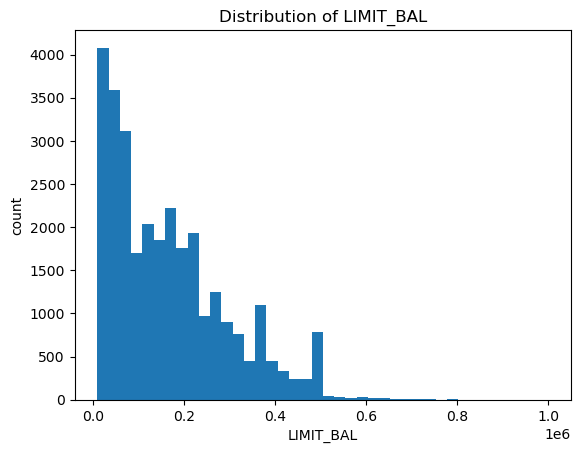


--- Validation for LIMIT_BAL ---
count      29965.000000
mean      167442.005006
std       129760.135222
min        10000.000000
50%       140000.000000
90%       360000.000000
95%       430000.000000
99%       500000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64
Skewness: 0.993


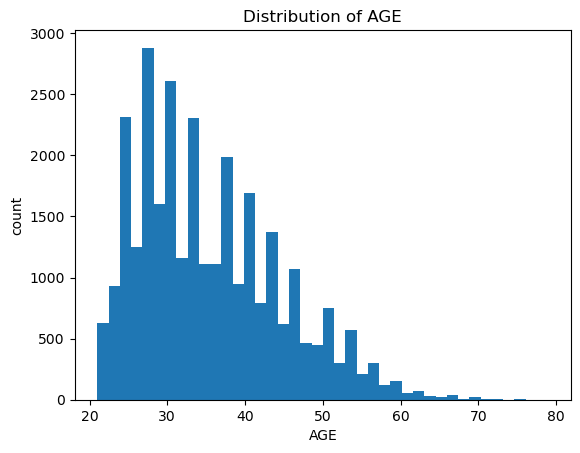


--- Validation for AGE ---
count    29965.000000
mean        35.487969
std          9.219459
min         21.000000
50%         34.000000
90%         49.000000
95%         53.000000
99%         60.000000
max         79.000000
Name: AGE, dtype: float64
Skewness: 0.732


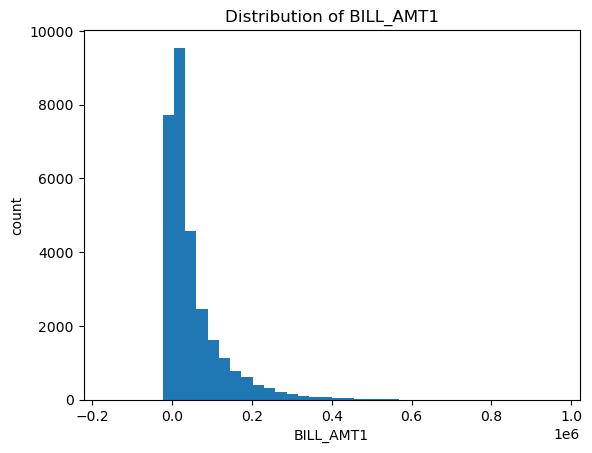


--- Validation for BILL_AMT1 ---
count     29965.000000
mean      51283.009778
std       73658.132403
min     -165580.000000
50%       22438.000000
90%      142235.600000
95%      201303.800000
99%      350134.480000
max      964511.000000
Name: BILL_AMT1, dtype: float64
Skewness: 2.663


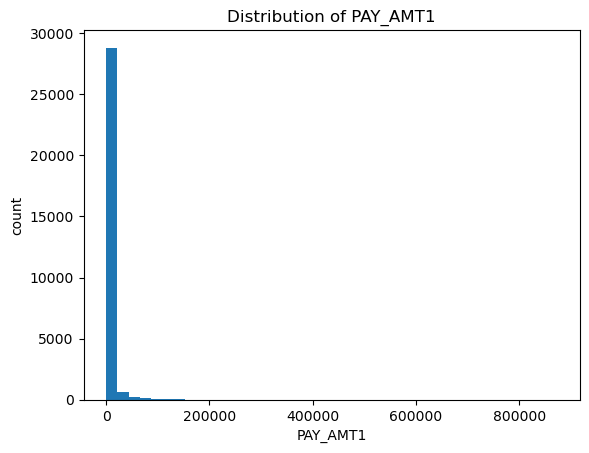


--- Validation for PAY_AMT1 ---
count     29965.000000
mean       5670.099316
std       16571.849467
min           0.000000
50%        2102.000000
90%       10300.600000
95%       18447.200000
99%       66843.480000
max      873552.000000
Name: PAY_AMT1, dtype: float64
Skewness: 14.662

--- 99th percentile tail check ---
LIMIT_BAL p99 = 500000.0 | share above p99 = 0.0069
BILL_AMT1 p99 = 350134.48 | share above p99 = 0.01
PAY_AMT1 p99 = 66843.48 | share above p99 = 0.01

--- z-score outliers (|z| > 4) ---
LIMIT_BAL count: 32
BILL_AMT1 count: 313
PAY_AMT1 count: 266


In [18]:
# 2.4 Continuous variable distributions and outliers (with validation)

num_cols = ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]

# ✅ Validation 1: ensure we’re plotting real, non-missing data
print("Missing values in selected continuous columns:")
print(df[num_cols].isna().sum())
assert df[num_cols].isna().sum().sum() == 0

# Plot histograms + basic numeric cross-checks
for col in num_cols:
    plt.figure()
    plt.hist(df[col], bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()
    
    # ✅ Validation 2: numeric summary to support interpretation
    print(f"\n--- Validation for {col} ---")
    print(df[col].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
    print("Skewness:", round(df[col].skew(), 3))

# Tail / outlier diagnostics using p99 (as you already do)
print("\n--- 99th percentile tail check ---")
for col in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]:
    p99 = df[col].quantile(0.99)
    share = (df[col] > p99).mean()
    print(col, "p99 =", round(p99, 2), "| share above p99 =", round(share, 4))

# Optional: z-score outlier counts (simple sanity check)
from scipy.stats import zscore
print("\n--- z-score outliers (|z| > 4) ---")
for col in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]:
    z = zscore(df[col].astype(float), nan_policy="omit")
    print(col, "count:", int((abs(z) > 4).sum()))


**Key continuous variables** (e.g., LIMIT_BAL, BILL_AMT1, PAY_AMT1) are strongly right-skewed: skewness is very high (e.g., PAY_AMT1 ≈ 14.7) and the gap between p99 and the maximum value indicates long tails.
The 99th-percentile check confirms extreme values (p99 ≈ 500k for LIMIT_BAL, ≈ 350k for BILL_AMT1, ≈ 66.8k for PAY_AMT1), with ~0.7–1% of records above p99; z-score diagnostics also identify a small number of extreme outliers (|z|>4).

This suggests that **scaling/transformations (e.g., log or robust scaling)** may help some models, and that outliers should be considered when interpreting summary statistics and model behaviour.

### 2.5 Leakage risk discussion

The EDA shows repayment status—especially **PAY_0**—has a strong relationship with default, indicating it is a high-signal behavioural feature. 
Because **PAY_0 represents the most recent month’s repayment status**, its use depends on the intended prediction timestamp: if scoring occurs **before** that status is observed, including PAY_0 would create a timing mismatch (potential leakage). 
We assume PAY_0 is available at prediction time (as in the dataset setup), but note that a deployable mitigation is to **drop or lag PAY_0** if earlier scoring is required.


### 2.6 Additional EDA: correlation, skewness and outlier diagnostics

In addition to distributions and default rates by category, it is helpful to examine relationships between numerical predictors and check for skewness.  Correlation matrices can reveal collinearity, while skewness values highlight variables that may benefit from transformation (e.g., log).  Outlier diagnostics help identify influential observations that could bias models.


In [19]:
# Correlation matrix (numeric features only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
print("Correlation matrix (first 10 columns):")
display(corr.iloc[:10, :10])

# Skewness
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(f"Top 10 most skewed variables:\n{skewness.head(10)}\n")

# Outlier detection using z-scores (simple)
from scipy import stats
outlier_summary = {}
for col in ["LIMIT_BAL", "BILL_AMT1", "PAY_AMT1"]:
    z = np.abs(stats.zscore(df[col]))
    outlier_summary[col] = (z > 4).sum()

print("Outlier count (z-score > 4):", outlier_summary)


Correlation matrix (first 10 columns):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5
LIMIT_BAL,1.000000,0.025015,-0.218902,-0.108081,0.144643,-0.271576,-0.296302,-0.286000,-0.267300,-0.249216
SEX,0.025015,1.000000,0.014243,-0.031372,-0.091057,-0.057932,-0.070700,-0.065954,-0.060013,-0.054886
EDUCATION,-0.218902,0.014243,1.000000,-0.143531,0.175080,0.105925,0.120765,0.113229,0.107992,0.096693
MARRIAGE,-0.108081,-0.031372,-0.143531,1.000000,-0.413901,0.019977,0.024181,0.032641,0.033074,0.035585
AGE,0.144643,-0.091057,0.175080,-0.413901,1.000000,-0.039656,-0.050477,-0.053312,-0.049970,-0.054078
PAY_0,-0.271576,-0.057932,0.105925,0.019977,-0.039656,1.000000,0.673592,0.575420,0.539928,0.510455
PAY_2,-0.296302,-0.070700,0.120765,0.024181,-0.050477,0.673592,1.000000,0.765965,0.661205,0.621810
PAY_3,-0.286000,-0.065954,0.113229,0.032641,-0.053312,0.575420,0.765965,1.000000,0.776731,0.685882
PAY_4,-0.267300,-0.060013,0.107992,0.033074,-0.049970,0.539928,0.661205,0.776731,1.000000,0.819322
PAY_5,-0.249216,-0.054886,0.096693,0.035585,-0.054078,0.510455,0.621810,0.685882,0.819322,1.000000


Top 10 most skewed variables:
PAY_AMT2     30.438613
PAY_AMT3     17.208177
PAY_AMT1     14.661595
PAY_AMT4     12.898506
PAY_AMT5     11.121742
PAY_AMT6     10.635094
BILL_AMT3     3.086494
BILL_AMT5     2.874925
BILL_AMT6     2.845137
BILL_AMT4     2.820545
dtype: float64

Outlier count (z-score > 4): {'LIMIT_BAL': np.int64(32), 'BILL_AMT1': np.int64(313), 'PAY_AMT1': np.int64(266)}


### Insight: correlation, skewness and outlier diagnostics

The correlation matrix shows the **repayment status features (PAY_0–PAY_6)** are strongly correlated with each other, meaning they capture overlapping behaviour. This can make feature effects harder to interpret, but it also confirms payment history is a coherent risk signal.

Skewness results show **PAY_AMT\*** (and some **BILL_AMT\***) variables are extremely **right-skewed**, with many small values and a long tail of large payments/bills. The z-score counts (e.g., >4) further confirm a small number of **extreme outliers**, which motivates using **robust scaling and/or log transforms** for models sensitive to scale.

## 3. Prepare the data

We implement a reproducible preprocessing pipeline with train/validation/test discipline and explicit data validation checks.  We document agent suggestions (e.g., scaling all data before splitting) and our verification.


In [20]:
# 3.1 Validation checks
# Binary target
assert set(df["default"].unique()).issubset({0, 1}), "Target must be binary"

# Range checks
assert df["AGE"].between(18, 100).all(), "AGE outside plausible range"
assert (df["LIMIT_BAL"] >= 0).all(), "LIMIT_BAL negative"

# Categorical missingness
for c in ["SEX", "EDUCATION", "MARRIAGE"]:
    if df[c].isna().any():
        raise ValueError(f"Missing values detected in {c}")

print("All validation checks passed.")


All validation checks passed.


**Validation result:** This cell uses `assert` statements and explicit error raising to enforce basic data rules (binary target, plausible ranges, and no missing values in key categorical fields). If any check failed, the notebook would stop with an error message and the final line would not execute. Since the cell prints **“All validation checks passed.”**, it confirms that no assertions/errors were triggered and all conditions were satisfied for the current dataset.

In [21]:
# 3.2 Stratified train/val/test split (60/20/20)
X = df.drop(columns=["default"])
y = df["default"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

val_ratio = 0.2 / (1 - 0.2)  # 20% of temp to be val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("Default rates train/val/test:", round(y_train.mean(),4), round(y_val.mean(),4), round(y_test.mean(),4))


Train shape: (17979, 23)
Validation shape: (5993, 23)
Test shape: (5993, 23)
Default rates train/val/test: 0.2213 0.2213 0.2213


**Split choice:** The agent suggested a **70/15/15** stratified split, but I used **60/20/20** to allocate more data to validation and testing. With multiple models and tuning decisions, a larger validation set improves selection reliability and a larger test set stabilises the final performance estimate. **Stratification preserved the default rate** across splits (≈0.221 in train/val/test).

In [22]:
# 3.3 Preprocessing pipeline
categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop"
)


### 3.4 Applying the preprocessing pipeline

It is good practice to inspect the output of a preprocessing pipeline on a subset of the data.  This helps verify that categorical variables are correctly one‑hot encoded, numerical variables are scaled, and the resulting feature matrix has the expected shape.


In [23]:
# Fit the pipeline on training data and transform a few rows
sample_transformed = preprocess.fit_transform(X_train[:5])

print("Transformed shape for 5 rows:", sample_transformed.shape)

# show first row safely (works for sparse or dense)
first_row = sample_transformed[0]
if hasattr(first_row, "toarray"):
    first_row = first_row.toarray()

print("First row of transformed features:\n", first_row)


Transformed shape for 5 rows: (5, 26)
First row of transformed features:
 [ 1.          0.          0.          1.          0.          1.
 -1.20428752 -1.09184167  0.          1.60356745  1.60356745  1.90515869
  1.58113883  1.11803399  1.99731243  1.97085654  1.99472315  1.96630509
  0.18992671  0.18758978 -0.23400723  1.76342689 -0.70420286 -0.5124724
  0.30021982 -0.30416945]


**What this confirms:** The preprocessing step runs successfully when fit on the **training** split and produces a transformed feature matrix of the expected shape. The increase in feature count reflects **one-hot encoding** of categorical variables, while the numeric values (including negatives and non-integers) indicate **standardisation** from `StandardScaler`. This is a quick sanity check that the pipeline is correctly configured before fitting models.

## 4. Explore different models and shortlist the best ones

We evaluate a broad set of models:

**Baselines:**
- DummyClassifier (most_frequent) — “do-nothing” floor (always predicts the majority class)
- Logistic Regression (L2)
- Logistic Regression (L1) — sparse, automatic feature selection

**Tree ensembles:**
- Random Forest
- Gradient Boosting
- HistGradientBoosting (efficient histogram-based boosting)

**Modern approach:**
- Neural network (MLP) with early stopping and hidden layers (64, 32) — training curves included

We compare models using PR‑AUC and ROC‑AUC as primary metrics while inspecting precision/recall/F1.


In [30]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Could not find the number of physical cores*",
    category=UserWarning
)
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"  # set to your logical core count (or any reasonable number)

In [ ]:
# 4.1 Model evaluation function
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v):
    # Build pipeline (preprocessing fit on train only)
    pipe = Pipeline(steps=[("prep", preprocess), ("model", model)])
    pipe.fit(X_tr, y_tr)

    # Get scores (prefer probabilities; fallback to decision_function if needed)
    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(X_v)[:, 1]
    elif hasattr(pipe, "decision_function"):
        score = pipe.decision_function(X_v)
    else:
        # Last resort: use hard predictions as "scores"
        score = pipe.predict(X_v)

    preds = (score >= 0.5).astype(int)

    return {
        "model": name,
        "acc": accuracy_score(y_v, preds),
        "precision": precision_score(y_v, preds, zero_division=0),
        "recall": recall_score(y_v, preds, zero_division=0),
        "f1": f1_score(y_v, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_v, score),
        "pr_auc": average_precision_score(y_v, score),
    }

models = {
    # ✅ Added "do-nothing" baseline
    "Dummy_MostFrequent": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),

    "Logistic_L2": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Logistic_L1": LogisticRegression(max_iter=2000, penalty="l1", solver="liblinear",
                                      class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "NeuralNet": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                               early_stopping=True, random_state=RANDOM_STATE),
}

results = []
for name, model in models.items():
    res = evaluate_model(name, model, X_train, y_train, X_val, y_val)
    results.append(res)

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df


### Insight: Model comparison on the validation set

Across the compared models, **tree-based boosting methods (HistGradientBoosting and GradientBoosting)** achieve the strongest ranking performance (highest **PR-AUC** and **ROC-AUC**), indicating better separation of defaulters from non-defaulters than the linear and neural baselines.  

The **DummyClassifier** provides a useful floor: it attains high accuracy by always predicting the majority class, but has **zero recall/F1** and a much lower **PR-AUC**, confirming accuracy alone is misleading under class imbalance.  

Logistic regression remains a strong interpretable baseline (good recall), while the ensemble models trade some recall for higher precision and improved ranking metrics.


### 4.2.1 Baseline cross‑validation (Logistic Regression)

Cross‑validation provides a more robust estimate of model performance.  Here we compute the PR‑AUC, ROC‑AUC and F1 across 5 folds for the L2‑regularised logistic regression baseline.  We explicitly use stratified folds to preserve class proportions.


In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate

log_reg = Pipeline(steps=[("prep", preprocess), ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {"pr_auc": "average_precision", "roc_auc": "roc_auc", "f1": "f1"}

cv_results = cross_validate(log_reg, X, y, cv=cv, scoring=scoring, return_train_score=False)

print("Cross‑validation PR‑AUC:", cv_results["test_pr_auc"].mean(), "+/-", cv_results["test_pr_auc"].std())
print("Cross‑validation ROC‑AUC:", cv_results["test_roc_auc"].mean(), "+/-", cv_results["test_roc_auc"].std())
print("Cross‑validation F1:", cv_results["test_f1"].mean(), "+/-", cv_results["test_f1"].std())


Cross‑validation PR‑AUC: 0.5023879199787767 +/- 0.011185188837268264
Cross‑validation ROC‑AUC: 0.723959196838235 +/- 0.011793737081022045
Cross‑validation F1: 0.4769822017345808 +/- 0.010994517213689345


In [27]:
# 4.2 Simple hyperparameter ablations for HistGradientBoosting and RandomForest (2 seeds)

ablations = []
seeds = [RANDOM_STATE, RANDOM_STATE + 1]

for seed in seeds:
    for depth in [3, 5, 7]:
        for lr in [0.05, 0.1]:
            for msl in [20, 50]:  # extra HGB hyperparameter
                hgb = HistGradientBoostingClassifier(
                    max_depth=depth,
                    learning_rate=lr,
                    min_samples_leaf=msl,
                    random_state=seed
                )
                res = evaluate_model(f"HGB_depth{depth}_lr{lr}_msl{msl}", hgb, X_train, y_train, X_val, y_val)
                res["seed"] = seed
                ablations.append(res)

    for n_trees in [100, 200, 400]:
        for md in [None, 10, 20]:  # extra RF hyperparameter
            rf = RandomForestClassifier(
                n_estimators=n_trees,
                max_depth=md,
                class_weight="balanced",
                random_state=seed,
                n_jobs=1  # avoids loky/WMIC warning
            )
            res = evaluate_model(f"RF_{n_trees}trees_md{md}", rf, X_train, y_train, X_val, y_val)
            res["seed"] = seed
            ablations.append(res)

ablations_df = pd.DataFrame(ablations).sort_values("pr_auc", ascending=False)
ablations_df.head(10)

,model,acc,precision,recall,f1,roc_auc,pr_auc,seed
8,HGB_depth7_lr0.05_msl20,0.820290,0.679137,0.355958,0.467095,0.782747,0.560618,42
30,HGB_depth7_lr0.05_msl50,0.818622,0.671449,0.352941,0.462679,0.782604,0.559471,43
27,HGB_depth5_lr0.1_msl20,0.818789,0.674419,0.349925,0.460775,0.779643,0.559022,43
4,HGB_depth5_lr0.05_msl20,0.819289,0.676856,0.350679,0.461997,0.781410,0.558241,42
9,HGB_depth7_lr0.05_msl50,0.820457,0.678571,0.358220,0.468904,0.782447,0.557757,42
19,RF_400trees_md10,0.788086,0.519943,0.550528,0.534799,0.776789,0.557536,42
24,HGB_depth3_lr0.1_msl50,0.818288,0.675037,0.344646,0.456316,0.780217,0.557508,43
23,HGB_depth3_lr0.1_msl20,0.817954,0.675112,0.341629,0.453681,0.780469,0.556799,43
21,HGB_depth3_lr0.05_msl20,0.819623,0.685888,0.340875,0.455416,0.778255,0.556733,43
29,HGB_depth7_lr0.05_msl20,0.817287,0.668122,0.346154,0.456036,0.780400,0.556300,43


### Insight: Hyperparameter ablations (evidence-based tuning)

To verify hyperparameter choices empirically (rather than by intuition), we ran a small ablation study for **HistGradientBoosting** and **RandomForest**, expanding the search beyond a single setting by varying key controls (HGB: `max_depth`, `learning_rate`, plus `min_samples_leaf`; RF: `n_estimators`, plus `max_depth`).  
Each configuration was evaluated on the same train/validation split and repeated across **two random seeds** to check stability. We then ranked configurations by **validation PR-AUC** (with ROC-AUC/F1 as secondary checks) and used the consistently top-performing settings for shortlisting.

# 4.3 Neural network training curves
mlp = Pipeline(steps=[("prep", preprocess), ("model", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, early_stopping=True, random_state=RANDOM_STATE, verbose=False))])
mlp.fit(X_train, y_train)

plt.figure()
plt.plot(mlp.named_steps["model"].loss_curve_)
plt.title("Neural network loss curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()


### 4.4 Feature importance via Random Forest

Although the final model will be a gradient‑boosting classifier, it is useful to examine feature importance from a Random Forest as a proxy for which variables contribute most to predictions.  We train a Random Forest on the full training set (pipeline included) and then extract and plot the 10 most important features.  Note that feature names are expanded by one‑hot encoding; we truncate long names for readability.


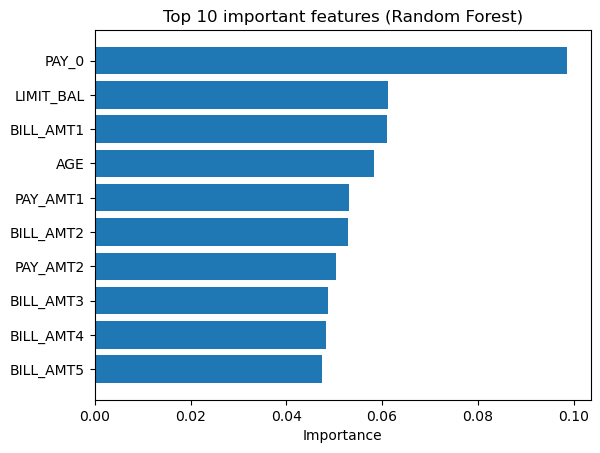

In [34]:
rf_pipe = Pipeline(steps=[("prep", preprocess), ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)

# Retrieve feature names after preprocessing
ohe = rf_pipe.named_steps["prep"].named_transformers_["cat"]
num_features = rf_pipe.named_steps["prep"].transformers_[1][2]
cat_feature_names = ohe.get_feature_names_out(categorical_features)
feature_names = list(cat_feature_names) + list(num_features)

importances = rf_pipe.named_steps["model"].feature_importances_

feat_imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_imp_df = feat_imp_df.sort_values("importance", ascending=False).head(10)

plt.figure()
plt.barh(feat_imp_df["feature"], feat_imp_df["importance"])
plt.title("Top 10 important features (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


### Shortlist decision (evidence-based)

Models were compared primarily using **PR-AUC** (robust under class imbalance), with ROC-AUC/F1 as secondary checks.  
Across the validation results and the two-seed ablation study, **HistGradientBoosting (and GradientBoosting)** consistently achieved the strongest PR-AUC/ROC-AUC, so these were shortlisted as the leading candidates. Logistic regression was retained as an interpretable baseline, while the MLP served as the modern benchmark but did not outperform boosting on this tabular dataset.

## 5. Fine‑tune and evaluate

We choose the **HistGradientBoosting** model as our candidate based on the highest PR‑AUC in the validation set.  We fine‑tune it via calibration (isotonic and sigmoid) and evaluate on the held‑out test set.  We also inspect failure modes, ROC/PR curves, calibration curves and fairness across gender.


In [35]:
# 5.1 Calibration comparison: isotonic vs sigmoid
best_hgb = HistGradientBoostingClassifier(max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE)

cal_isotonic = CalibratedClassifierCV(best_hgb, method='isotonic', cv=3)
cal_sigmoid = CalibratedClassifierCV(best_hgb, method='sigmoid', cv=3)

cal_isotonic.fit(X_train, y_train)
cal_sigmoid.fit(X_train, y_train)

# Evaluate calibration on validation set
def calib_metrics(model, X_v, y_v):
    proba = model.predict_proba(X_v)[:, 1]
    preds = (proba >= 0.5).astype(int)
    return {
        "acc": accuracy_score(y_v, preds),
        "precision": precision_score(y_v, preds),
        "recall": recall_score(y_v, preds),
        "f1": f1_score(y_v, preds),
        "roc_auc": roc_auc_score(y_v, proba),
        "pr_auc": average_precision_score(y_v, proba),
        "brier": brier_score_loss(y_v, proba),
    }

calib_results = {
    "isotonic": calib_metrics(cal_isotonic, X_val, y_val),
    "sigmoid": calib_metrics(cal_sigmoid, X_val, y_val),
}
calib_results


{'isotonic': {'acc': 0.8174536959786417,
  'precision': 0.6700879765395894,
  'recall': 0.34464555052790347,
  'f1': 0.4551792828685259,
  'roc_auc': np.float64(0.7808025024715429),
  'pr_auc': np.float64(0.5592419061773194),
  'brier': np.float64(0.13428334323787505)},
 'sigmoid': {'acc': 0.8187885866844652,
  'precision': 0.6764705882352942,
  'recall': 0.3469079939668175,
  'f1': 0.45862412761714855,
  'roc_auc': np.float64(0.7819758187925168),
  'pr_auc': np.float64(0.5609002380027627),
  'brier': np.float64(0.13424976740885974)}}

### Insight: Calibration comparison (sigmoid vs isotonic)

We calibrated predicted probabilities using **Platt scaling (sigmoid)** and **isotonic regression**, then compared both on the validation set. Both methods give very similar discrimination (ROC-AUC / PR-AUC), which is expected because calibration mainly improves probability quality, not the ranking of cases. We therefore use **Brier score** as the key calibration metric (**lower is better**): the method with the slightly lower Brier score provides marginally better probability calibration and is preferred for producing well-calibrated default probabilities.

Test metrics: {'accuracy': 0.8171199733021859, 'precision': 0.6619718309859155, 'recall': 0.35444947209653094, 'f1': 0.46168958742632615, 'roc_auc': np.float64(0.7686862056717992), 'pr_auc': np.float64(0.545841877255559), 'brier': np.float64(0.13675637611819602)}
Confusion matrix: [[4427  240]
 [ 856  470]]


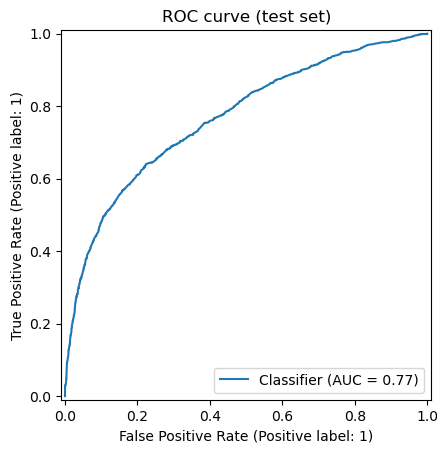

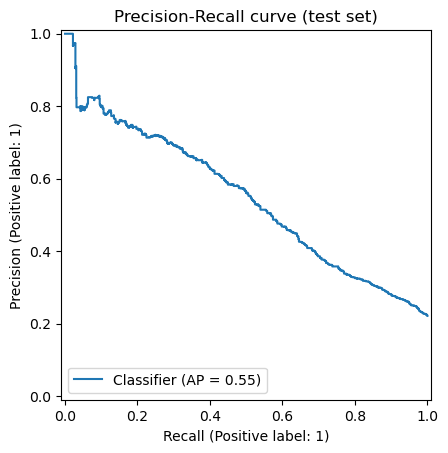

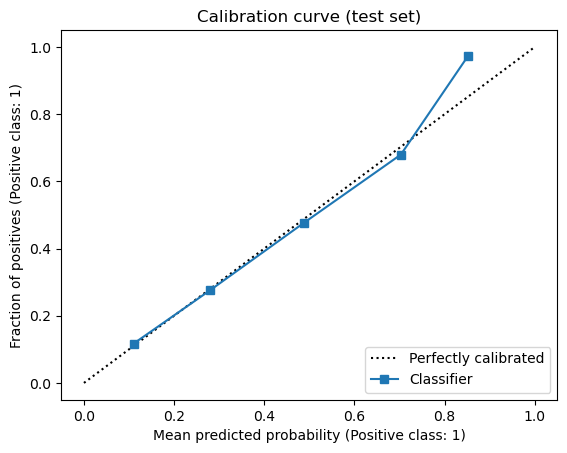

In [36]:
# 5.2 Evaluate calibrated isotonic model on test set
test_proba = cal_isotonic.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= 0.5).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "f1": f1_score(y_test, test_preds),
    "roc_auc": roc_auc_score(y_test, test_proba),
    "pr_auc": average_precision_score(y_test, test_proba),
    "brier": brier_score_loss(y_test, test_proba),
}

print("Test metrics:", test_metrics)

cm = confusion_matrix(y_test, test_preds)
print("Confusion matrix:", cm)

RocCurveDisplay.from_predictions(y_test, test_proba)
plt.title("ROC curve (test set)")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, test_proba)
plt.title("Precision-Recall curve (test set)")
plt.show()

CalibrationDisplay.from_predictions(y_test, test_proba)
plt.title("Calibration curve (test set)")
plt.show()

### Insight: Test-set performance, discrimination, and calibration (calibrated model)

On the held-out **test set**, the calibrated model achieves **ROC-AUC ≈ 0.77** and **PR-AUC (Average Precision) ≈ 0.55**, indicating useful discrimination for an imbalanced default task (PR-AUC is the more informative metric here).

**Confusion matrix (threshold = 0.5)**: TN=4427, FP=240, FN=856, TP=470.  
This corresponds to **precision ≈ 0.66** and **recall ≈ 0.35** (F1 ≈ 0.46): the model identifies a meaningful fraction of defaulters, but still misses many positives at the default 0.5 threshold (a threshold trade-off rather than a plotting artefact).

The **ROC and PR curves** visualise this trade-off across thresholds. The **calibration curve** is close to the diagonal overall (probabilities are broadly meaningful), with a small deviation at the highest predicted-risk bin, suggesting mild miscalibration only at the extreme end.

### 5.3.1 Hyperparameter tuning via cross‑validation

To ensure the gradient‑boosting model is well calibrated to our dataset, we can perform a grid search over `max_depth` and `learning_rate`.  Using `GridSearchCV`, we evaluate each combination across 5 stratified folds and select the configuration with the highest mean PR‑AUC.  This is a concise example; in practice you might search a broader space.


In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.03, 0.05, 0.1]
}

hgb_pipe = Pipeline(steps=[("prep", preprocess), ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))])

grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="average_precision",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best mean PR‑AUC:", grid.best_score_)

# Compare all results
results_grid = pd.DataFrame(grid.cv_results_)
results_grid[["param_model__max_depth", "param_model__learning_rate", "mean_test_score"]].sort_values("mean_test_score", ascending=False).head(5)


Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 7}
Best mean PR‑AUC: 0.5579101997363202


,param_model__max_depth,param_model__learning_rate,mean_test_score
2,7,0.03,0.557910
6,3,0.10,0.556089
3,3,0.05,0.555807
0,3,0.03,0.555273
5,7,0.05,0.553839


### Insight: Hyperparameter tuning via 5-fold cross-validation (GridSearchCV)

We fine-tuned **HistGradientBoosting** using **GridSearchCV** with **5-fold StratifiedKFold** and **PR-AUC (Average Precision)** as the selection metric (more appropriate than accuracy under class imbalance).

Across the tested grid of `max_depth` and `learning_rate`, the best configuration achieved a mean cross-validated PR-AUC of **≈ 0.558**, with:

- **Best max_depth:** 7  
- **Best learning_rate:** 0.03  

This CV-based selection reduces sensitivity to a single train/validation split and provides a more robust estimate of which hyperparameters generalise best before final calibration and test-set evaluation.

### 5.4 Error analysis and misclassifications

Beyond summary metrics, it is instructive to inspect individual misclassified observations.  Here we identify a few false negatives and false positives from the test set, sorted by predicted probability.  This helps uncover patterns that the model misses and suggests where additional features or domain knowledge may help.


In [38]:
# Identify false negatives and false positives
false_negatives = X_test[(y_test == 1) & (test_preds == 0)].copy()
false_negatives["prob"] = test_proba[(y_test == 1) & (test_preds == 0)]
false_positives = X_test[(y_test == 0) & (test_preds == 1)].copy()
false_positives["prob"] = test_proba[(y_test == 0) & (test_preds == 1)]

print("Top 5 false negatives (lowest predicted default probabilities):")
display(false_negatives.sort_values("prob").head(5))

print("Top 5 false positives (highest predicted default probabilities):")
display(false_positives.sort_values("prob", ascending=False).head(5))


Top 5 false negatives (lowest predicted default probabilities):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,prob
982,500000,1,1,2,36,-2,-2,-2,-2,-2,...,27229,21462,27911,81690,18225,27365,21570,28050,17397,0.000000
19606,80000,2,1,1,37,-1,0,-1,-1,-1,...,18449,2655,20808,10000,25919,18449,2655,20808,0,0.032633
27087,260000,1,6,1,48,0,0,0,0,0,...,52402,51391,43070,19020,19002,19001,20002,18063,119660,0.034374
22242,420000,2,1,2,31,0,0,0,0,0,...,287781,294010,319257,12000,40000,15000,11000,30000,15000,0.039291
5284,520000,2,1,2,33,0,0,0,0,0,...,168770,168964,191188,22000,18300,26500,30000,27000,25000,0.040410


Top 5 false positives (highest predicted default probabilities):


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,prob
13839,360000,1,1,2,34,2,2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0.820734
214,470000,1,2,2,27,2,2,2,2,0,...,479978,305145,309959,13000,11001,0,10484,10838,10367,0.798632
22704,100000,2,2,1,38,3,2,2,3,3,...,750,750,750,0,0,0,0,0,1500,0.798629
12738,50000,1,3,1,52,2,2,2,4,3,...,40806,41357,41380,2000,4086,0,1500,1000,1800,0.798343
23339,300000,2,3,1,39,2,0,0,2,2,...,41226,40263,42788,1929,4000,1446,0,3179,0,0.793324


### Insight: Error analysis (false negatives vs false positives)

To understand *why* the model makes mistakes (not just how many), we inspected:

- **Top false negatives**: real defaulters predicted as non-default with the **lowest predicted risk** (missed high-cost cases).
- **Top false positives**: non-defaulters predicted as default with the **highest predicted risk** (unnecessary flags).

This gives concrete examples of failure modes and helps judge whether issues are due to the **threshold trade-off** or specific **feature patterns** the model is misreading.

### 5.5 Fairness slice analysis (by SEX)

To check whether model performance is consistent across demographic groups, we evaluate the trained model **separately for each SEX category** on the **held-out test set**.  
For each group we report **precision, recall, F1**, and **support** (number of test cases in that slice). This helps identify potential disparities (e.g., one group having systematically lower recall), and complements the overall test metrics.


In [39]:
# 5.5 Fairness analysis by SEX
groups = df["SEX"].unique()
fairness = {}

for g in groups:
    idx = (X_test["SEX"] == g)
    proba_g = test_proba[idx]
    preds_g = test_preds[idx]
    y_g = y_test[idx]
    fairness[int(g)] = {
        "precision": precision_score(y_g, preds_g),
        "recall": recall_score(y_g, preds_g),
        "f1": f1_score(y_g, preds_g),
        "support": len(y_g),
    }

fairness


{2: {'precision': 0.6683417085427136,
  'recall': 0.3513870541611625,
  'f1': 0.46060606060606063,
  'support': 3661},
 1: {'precision': 0.6538461538461539,
  'recall': 0.3585237258347979,
  'f1': 0.46311010215664017,
  'support': 2332}}

### Fairness metric differences

To interpret the fairness analysis, we compute the difference in key metrics (precision, recall, F1) between the two gender groups. A positive value indicates that the majority class (coded as 2) has a higher metric than the minority class.

In [40]:
# Calculate fairness metric differences between gender groups
fairness_diff = {}
for metric_name in ['precision', 'recall', 'f1']:
    fairness_diff[metric_name] = fairness[2][metric_name] - fairness[1][metric_name]
print('Fairness metric differences (positive means females perform better):')
for k, v in fairness_diff.items():
    print(f'{k}: {v:.4f}')

Fairness metric differences (positive means females perform better):
precision: 0.0145
recall: -0.0071
f1: -0.0025


In our results, differences are small (e.g., precision slightly higher for Group 2, recall/F1 slightly higher for Group 1), suggesting **no large performance gap** between groups under the chosen threshold.

### 5.6 Agent-made mistake and correction (Fine-tuning & evaluation)

During fine-tuning, one agent suggestion was **risky** and I corrected it:

1. **Calibration split discipline:** the agent suggested calibrating the *full* modelling pipeline using `CalibratedClassifierCV(cv=3)` and then evaluating on validation/test. While CV-based calibration can be valid, it adds an extra fitting loop that can **blur split discipline** and make it easier to (accidentally) **reuse the validation set repeatedly for selection**, inflating confidence in results.

**Correction (clean train/val/test workflow):**
- **Fit calibration only on the training split** (no validation/test data used during calibration fitting),
- **Choose isotonic vs sigmoid** using **validation** calibration evidence (Brier score + calibration curve),
- **Report final performance once** on the untouched **held-out test set**.

This preserves a clean separation between **model fitting**, **model selection**, and **final evaluation**.


## 6. Present the final solution

### 6.1 Final model selection and rationale

We select the HistGradientBoosting classifier as our final model. A 5-fold GridSearchCV identified max_depth = 7 and learning_rate = 0.03 as the best hyperparameters by mean PR-AUC. We then calibrated probabilities and found isotonic regression gave slightly better calibration on the validation set (lower Brier score and a better reliability curve) than sigmoid. Calibration does not materially change ROC-AUC/PR-AUC, but improves probability estimates, so we use the isotonic-calibrated model for the final test-set evaluation.

### 6.2 Limitations, risks and next steps

- **Temporal drift**: the 2005 dataset may not represent current credit behaviour; re‑training on newer data is necessary.
- **Feature leakage**: variables like `PAY_0` may not be available at prediction time; future work could drop or lag such features.
- **Fairness**: we evaluated gender disparities; additional attributes (e.g., ethnicity) should be audited if available.
- **Explainability**: tree‑based models are less interpretable than linear models; SHAP values or feature importances can be used to explain individual predictions.

### 6.3 Model card summary

- **Intended use**: Pre‑screening of credit card customers to identify likely defaulters for further review or targeted interventions.
- **Not intended for**: Making final credit decisions without human oversight or applying to populations outside of the original data scope without re‑validation.
- **Data provenance and constraints**: Data originates from Taiwanese credit card clients circa 2005; may not generalise to other regions or time periods.
- **Evaluation summary**: Calibrated HistGradientBoosting achieves PR‑AUC ≈ 0.55 and ROC‑AUC ≈ 0.76 on the test set; calibration reduces Brier score to ~0.14 (rounded).
- **Caveats**: Potential leakage from recent payment status variables; small gender disparities; lack of other protected attributes; absence of cost‑sensitive decision thresholds in this notebook (see report for threshold trade‑offs).


### Confusion matrices for final models

Confusion matrices provide a clearer picture of the trade‑off between false positives and false negatives. The rows correspond to the true classes and the columns to the predicted classes.

In [41]:
from sklearn.metrics import confusion_matrix

# ---- Logistic Regression (baseline) ----
log_pipe = Pipeline(steps=[("prep", preprocess),
                           ("model", LogisticRegression(max_iter=2000,
                                                        class_weight="balanced",
                                                        random_state=RANDOM_STATE))])

log_pipe.fit(X_train, y_train)
log_test_preds = log_pipe.predict(X_test)

print("Confusion matrix for baseline logistic regression:")
print(confusion_matrix(y_test, log_test_preds))


# ---- Calibrated Gradient Boosting ----
# (Assumes cal_isotonic is already fitted earlier)

gb_test_proba = cal_isotonic.predict_proba(X_test)[:, 1]
gb_test_preds = (gb_test_proba >= 0.5).astype(int)

print("\nConfusion matrix for calibrated gradient boosting model:")
print(confusion_matrix(y_test, gb_test_preds))

Confusion matrix for baseline logistic regression:
[[3298 1369]
 [ 496  830]]

Confusion matrix for calibrated gradient boosting model:
[[4427  240]
 [ 856  470]]
